# Oxford

## Data Processing & Cleaning

Table of contents: 
- monocentric analysis
- polycentric analysis
- Moran I's plot
- population analysis

Exploring where cafés and shops sit relative to where people live across cities in England. 

Method: distance from each LSOA centroid to its nearest few POIs, and tested whether access falls off with distance from the centre (e.g., Carfax Tower in Oxford).

Null (H0): there's no relationship between distance-from-centre and access. 
Alternative (H1): there is a relationship — the further out, the worse the access.

In [1]:
# Import libraries
import black
import jupyter_black
import pandas as pd
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
import numpy as np
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
import libpysal
from esda.moran import Moran

### LSOAs

In [2]:
# Read into boundary file of LSOAs defined in December 2021 for England and Wales
lsoas_gdf = gpd.read_file(
    "/Users/giorgiadimiccoli/Desktop/repos/projects/oxford-cycling-gis/Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BFE_V10_5579272939529726760.gpkg"
)

# Extract Oxford's LSOAs
oxford_lsoas_gdf = lsoas_gdf[lsoas_gdf["LSOA21NM"].str.startswith("Oxford")]

# Explore geodataframe
oxford_lsoas_gdf.head(2)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
27067,E01028513,Oxford 005A,,455386,207847,51.766579,-1.19879,{AD6D8B73-8B1F-4B6C-95BD-66B988273DE8},"MULTIPOLYGON (((455140.299 208226.459, 455139...."
27068,E01028514,Oxford 005B,,455784,207805,51.766159,-1.19303,{F217F7D9-C1F3-41C5-93BD-CEBE2D5EBDD8},"MULTIPOLYGON (((455652.478 208055.375, 455650...."


### POIs

In [3]:
# Download points of interests in Oxford
oxford_pois_df = ox.features_from_place(
    "Oxford, England", {"amenity": ["cafe", "restaurant", "bar"]}
)

# Reproject POIs so that they have the same CRS as the LSOA dataframe
oxford_pois_reprojected = oxford_pois_df.to_crs(oxford_lsoas_gdf.crs).copy()

# one tidy point per POI
oxford_pois_reprojected["geometry"] = (
    oxford_pois_reprojected.geometry.representative_point()
)  

oxford_pois_reprojected.head(2)

geometry addr:city addr:housenumber  \
element id                                                                    
node    231413379  POINT (451076.794 206437.902)    Oxford          100-101   
        251232416  POINT (451006.802 206459.039)    Oxford              NaN   

                  addr:postcode       addr:street     amenity breakfast  \
element id                                                                
node    231413379       OX1 2DF  Gloucester Green  restaurant        no   
        251232416       OX1 2BU  Gloucester Green  restaurant        no   

                   check_date                              contact:facebook  \
element id                                                                    
node    231413379  2025-06-15    https://www.facebook.com/100percent.pasta/   
        251232416  2025-06-15  https://www.facebook.com/Sichuangrandlondon/   

                                               contact:instagram  ...  \
element id                                                        ...   
node    231413379    https://www.instagram.com/100percent.pasta/  ...   
        251232416  https://www.instagram.com/sichuangrand/?hl=en  ...   

                  opening_hours:delivery source:building drink  \
element id                                                       
node    231413379                    NaN             NaN   NaN   
        251232416                    NaN             NaN   NaN   

                  building:colour building:material opening_date landuse  \
element id                                                                 
node    231413379             NaN               NaN          NaN     NaN   
        251232416             NaN               NaN          NaN     NaN   

                  start_date food:meal food:sandwich  
element id                                            
node    231413379        NaN       NaN           NaN  
        251232416        NaN       NaN           NaN  

[2 rows x 177 columns]

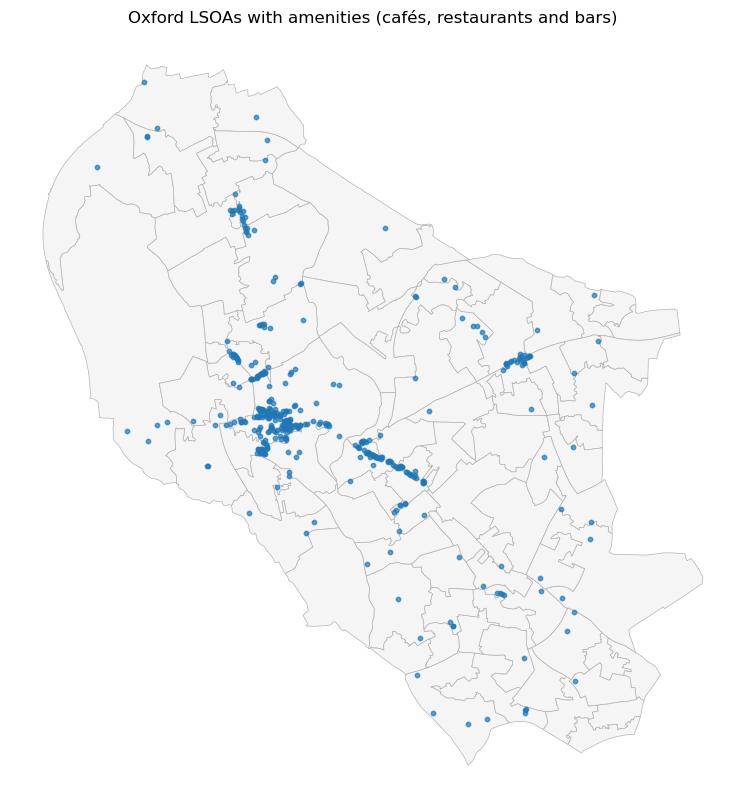

In [4]:
# Plotting amenities across LSOAs in Oxford
fig, ax = plt.subplots(figsize=(10, 10))

# base: the neighbourhoods
oxford_lsoas_gdf.plot(ax=ax, facecolor="whitesmoke", edgecolor="0.7", linewidth=0.5)

# overlay: the POIs
oxford_pois_reprojected.plot(
    ax=ax, markersize=10, alpha=0.7, legend=True
)

ax.set_title("Oxford LSOAs with amenities (cafés, restaurants and bars)")
ax.set_axis_off()
plt.show()

In [5]:
# Build a dataframe of centroids for each LSOA
oxford_centroids_gdf = gpd.GeoDataFrame(
    oxford_lsoas_gdf[["LSOA21CD"]],
    geometry=gpd.points_from_xy(oxford_lsoas_gdf.BNG_E, oxford_lsoas_gdf.BNG_N), # using British National Grid Easting 
    # and Northing coordinates
    crs=27700,
)
oxford_centroids_gdf.head(2)

,LSOA21CD,geometry
27067,E01028513,POINT (455386 207847)
27068,E01028514,POINT (455784 207805)


In [6]:
# Reproject POIs to BNG so both layers are in the same CRS
oxford_pois_bng = oxford_pois_df.to_crs(27700).copy()
oxford_pois_bng["geometry"] = oxford_pois_bng.geometry.representative_point()
oxford_pois_bng.head(2)

geometry addr:city addr:housenumber  \
element id                                                                    
node    231413379  POINT (451076.794 206437.902)    Oxford          100-101   
        251232416  POINT (451006.802 206459.039)    Oxford              NaN   

                  addr:postcode       addr:street     amenity breakfast  \
element id                                                                
node    231413379       OX1 2DF  Gloucester Green  restaurant        no   
        251232416       OX1 2BU  Gloucester Green  restaurant        no   

                   check_date                              contact:facebook  \
element id                                                                    
node    231413379  2025-06-15    https://www.facebook.com/100percent.pasta/   
        251232416  2025-06-15  https://www.facebook.com/Sichuangrandlondon/   

                                               contact:instagram  ...  \
element id                                                        ...   
node    231413379    https://www.instagram.com/100percent.pasta/  ...   
        251232416  https://www.instagram.com/sichuangrand/?hl=en  ...   

                  opening_hours:delivery source:building drink  \
element id                                                       
node    231413379                    NaN             NaN   NaN   
        251232416                    NaN             NaN   NaN   

                  building:colour building:material opening_date landuse  \
element id                                                                 
node    231413379             NaN               NaN          NaN     NaN   
        251232416             NaN               NaN          NaN     NaN   

                  start_date food:meal food:sandwich  
element id                                            
node    231413379        NaN       NaN           NaN  
        251232416        NaN       NaN           NaN  

[2 rows x 177 columns]

In [7]:
# For every centroid, find nearest POI across all POIs
oxford_centroids_and_pois_gdf = oxford_centroids_gdf.sjoin_nearest(
    oxford_pois_bng, distance_col="dist_to_nearest_poi"
)
oxford_access_scores_df = oxford_centroids_and_pois_gdf[["LSOA21CD", "dist_to_nearest_poi"]]
oxford_access_scores_df.head(2)

,LSOA21CD,dist_to_nearest_poi
27067,E01028513,207.056247
27068,E01028514,296.396058


In [8]:
lsoas_gdf.head(2)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01000001,City of London 001A,,532123,181632,51.518169,-0.09715,{A5D3008F-FBD3-45AB-8E36-46DED7FA6EB9},"MULTIPOLYGON (((532151.537 181867.433, 532149...."
1,E01000002,City of London 001B,,532480,181715,51.518829,-0.09197,{73AD1BEF-5C83-4CF4-9185-A6B2E2079949},"MULTIPOLYGON (((532634.497 181926.016, 532632...."


In [9]:
# Hardcode the coordinates of the city centre of Oxford (Carfax Tower)
cx, cy = 451306, 206177

# Merge access scores with the LSOA coordinates
oxf_access_df = oxford_lsoas_gdf[["LSOA21CD", "BNG_E", "BNG_N"]].merge(
    oxford_access_scores_df, on="LSOA21CD"
)

# Calculate the distance from the centroid of each LSOA to the city centre
oxf_access_df["dist_to_city_centre"] = (
    (oxf_access_df.BNG_E - cx) ** 2 + (oxf_access_df.BNG_N - cy) ** 2
) ** 0.5

oxf_access_df.head(2)

,LSOA21CD,BNG_E,BNG_N,dist_to_nearest_poi,dist_to_city_centre
0,E01028513,455386,207847,207.056247,4408.548514
1,E01028514,455784,207805,296.396058,4764.752669


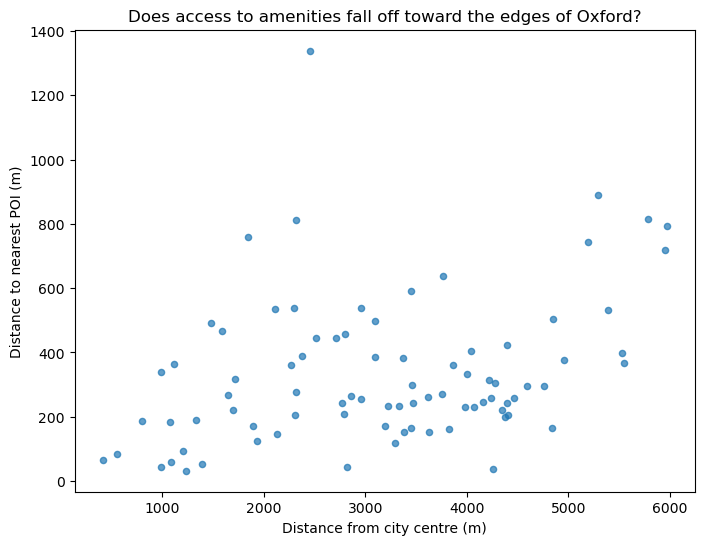

In [10]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
oxf_access_df.plot.scatter(
    ax=ax, x="dist_to_city_centre", y="dist_to_nearest_poi", alpha=0.7
)
ax.set_xlabel("Distance from city centre (m)")
ax.set_ylabel("Distance to nearest POI (m)")
ax.set_title("Does access to amenities fall off toward the edges of Oxford?")
plt.show()

In [11]:
# Computing Pearson coefficient and p-value to check the strength of the relationship
r, p = stats.pearsonr(
    oxf_access_df["dist_to_city_centre"], oxf_access_df["dist_to_nearest_poi"]
)
print(f"r = {r:.2f},  p = {p:.3f}")

r = 0.32,  p = 0.003


There is a positive but weak relationship (r = 0.32) between each LSOA's distance to Oxford city centre and its distance to the nearest POI. This suggests that LSOAs nearer the centre tend to have amenities closer at hand.

Moreover,  a tiny p-value (your 0.3%) means that outer Oxford neighbourhoods do tend to have slightly worse access to amenities, and that pattern is probably real rather than just chance — but it's weak, which hints that Oxford isn't built around a single centre.

In fact, distance to the centre explains only part of the variation in access. The map we plotted above shows why: Oxford's amenities form several distinct clusters rather than one central concentration (Cowley Road, Headington, Summertown), so a single-centre measure understates access for areas near secondary hubs. Let's therefore go ahead and use a K-means model to explore these clusters further.

## Polycentric Analysis

In [12]:
# Cluster POIs to find the cluster centres
coords = np.column_stack([oxford_pois_reprojected.geometry.x, oxford_pois_reprojected.geometry.y])

# Fit K-means to find 5 amenity clusters 
kmeans = KMeans(n_clusters=5, random_state=0).fit(coords)
cluster_centres = kmeans.cluster_centers_
print(f'{cluster_centres=}')

# Assign each POI to its nearest cluster
cluster_label = kmeans.predict(coords)
print(f'{cluster_label[:10]=}')

oxford_pois_reprojected["cluster"] = cluster_label

cluster_centres=array([[452725.03042777, 205657.84246277],
       [451156.33853127, 206391.15746726],
       [454334.05729832, 203549.0230447 ],
       [454468.58249932, 207192.05232077],
       [450730.40570465, 209192.79801697]])
cluster_label[:10]=array([1, 1, 0, 1, 0, 4, 0, 0, 1, 1], dtype=int32)


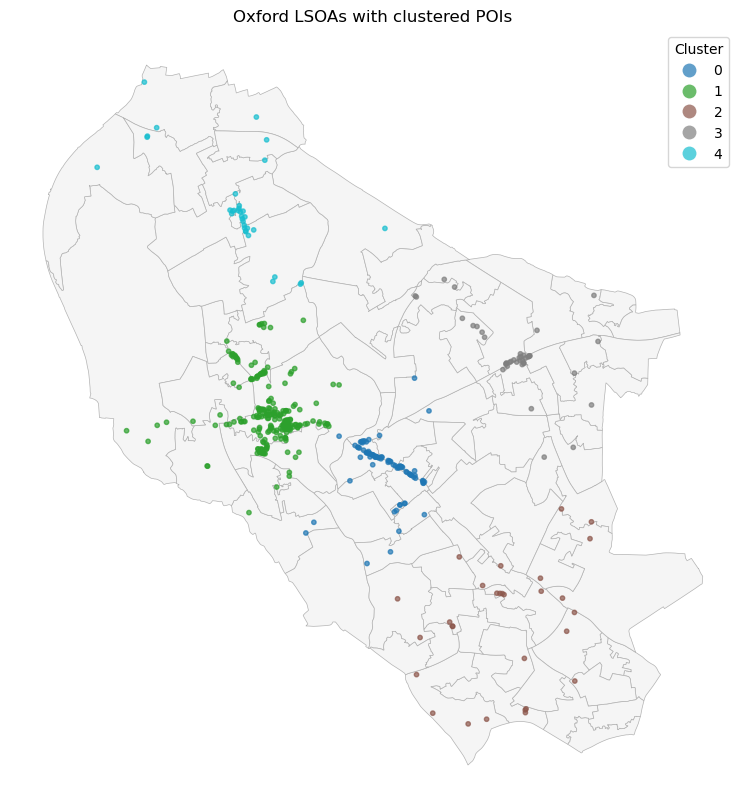

In [13]:
# Plot clustered POIs
fig, ax = plt.subplots(figsize=(10, 10))

# base: the neighbourhoods
oxford_lsoas_gdf.plot(
    ax=ax, 
    facecolor="whitesmoke", 
    edgecolor="0.7", 
    linewidth=0.5
)

oxford_pois_reprojected.plot(
    ax=ax,
    column="cluster",
    categorical=True,
    cmap="tab10",
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={"title": "Cluster", "loc": "upper right"},
)

ax.set_title("Oxford LSOAs with clustered POIs")
ax.set_axis_off()
plt.show()

Looking back at the map, we can confirm that Oxford does not have a single central hub of amenities. Rather, it has multiple, and they are spread across the city. This explains why our first model showed a weak relationship (r=0.32) between LSOAs distance to the city centre and LSOAs distance to nearest POI. If there was one predominant centre, this distance would predict access to amenities well. However, it gives us only a partial picture.

In [14]:
# Find distance from each LSOA's centroid to its nearest cluster centre
tree = cKDTree(cluster_centres)
dists, closest_cluster = tree.query(oxf_access_df[["BNG_E", "BNG_N"]].values)
oxf_access_df["dist_to_nearest_cluster_centre"] = dists
oxf_access_df["nearest_cluster"] = closest_cluster

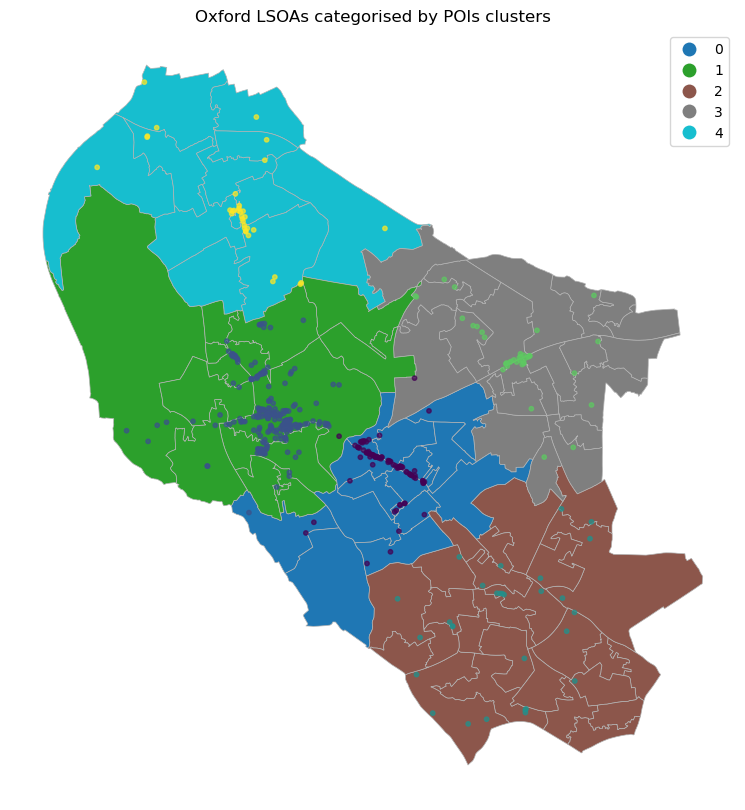

In [15]:
# Plotting LSOAs based on POIs clusters' categories
fig, ax = plt.subplots(figsize=(10, 10))

# base: the neighbourhoods
oxford_lsoas_gdf.plot(
    ax=ax,
    column=oxf_access_df["nearest_cluster"].values,  # values to colour by
    categorical=True,                          # discrete colours, not a gradient
    cmap="tab10",                              # qualitative colormap
    legend=True,
    edgecolor="0.7",
    linewidth=0.5,
)

# overlay: the POIs, coloured by type
oxford_pois_reprojected.plot(
    ax=ax, markersize=10, alpha=0.7, legend=True, c=cluster_label,
)

ax.set_title("Oxford LSOAs categorised by POIs clusters")
ax.set_axis_off()
plt.show()

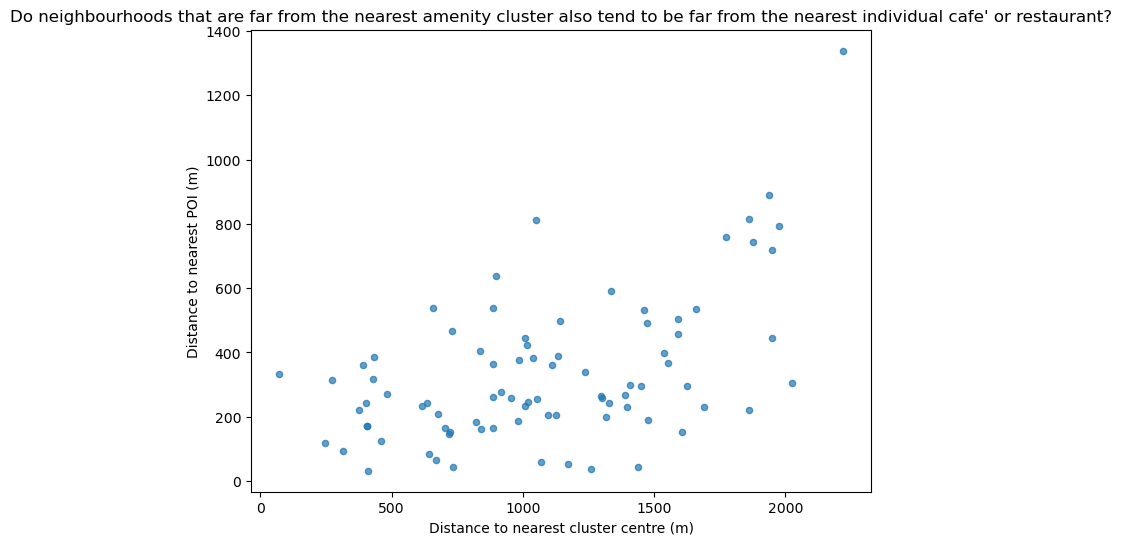

In [16]:
# Check the relationship between the distance of the LSOA's centroid
# to the nearest cluster centre vs the distance from the LSOA's centroid's to their nearest POI
fig, ax = plt.subplots(figsize=(8, 6))
oxf_access_df.plot.scatter(
    ax=ax, x="dist_to_nearest_cluster_centre", y="dist_to_nearest_poi", alpha=0.7
)
ax.set_xlabel("Distance to nearest cluster centre (m)")
ax.set_ylabel("Distance to nearest POI (m)")
ax.set_title(
    "Do neighbourhoods that are far from the nearest amenity cluster also tend to be far from the nearest individual cafe' or restaurant?"
)
plt.show()

In [17]:
r, p = stats.pearsonr(
    oxf_access_df["dist_to_nearest_cluster_centre"],
    oxf_access_df["dist_to_nearest_poi"],
)
print(f"r = {r:.2f},  p = {p:.3f}")

r = 0.52,  p = 0.000


The relationship we found between each LSOA's distance to their nearest cluster and its distance to the nearest POI is strong by construction. This is because we are using the same POI locations on both variables. Therefore, this relationship illustrates that there are multiple amenities' hubs, it does not prove it. The map is the real evidence.

Going back to the first model, we must challenge the credibility of our p-value (p = 0.003). This is because it made a hidden assumption, that is, 84 neighbourhoods are independent observations. However, the neighbourhoods we are analysing share the same amenities and could most probably echo each other. Therefore we will now use Moran's I  plot to check whether the p-value test overstates how sure it can be. 

## Moran I's Analysis: Checking Spatial Independence

Up until now, we have built two distance models, and both assumed spatial independence - each of the 84 LSOAs was a statistically independent observation, uncorrelated with the others. The correlation we found with the Pearson coefficient depends on this assumption. However, neighbouring LSOAs may have similar acces values simply because they sit close together and share the same nearby amenities. Let's test this using Moran's I, which is a measure of spatial autocorrelation. 

So let's use Moran's I plot to answer the following questions: 

1. "Do neighbouring LSOAs tend to have similar values of distance to the nearest POI, or are those values scattered randomly across the city?". We will do this by passing in dist_to_nearest_poi".

2. "Does the result of the first question threaten my p-value?"

### 1st Question

"Do neighbouring LSOAs tend to have similar values of distance to the nearest POI, or are those values scattered randomly across the city?". We will do this by passing in dist_to_nearest_poi".

In [18]:
# Build a clean GeoDataFrame
# Merge access measures onto the LSOA polygons
gdf = oxford_lsoas_gdf.merge(
    oxf_access_df,
    on='LSOA21CD'
)
gdf.head(2)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E_x,BNG_N_x,LAT,LONG,GlobalID,geometry,BNG_E_y,BNG_N_y,dist_to_nearest_poi,dist_to_city_centre,dist_to_nearest_cluster_centre,nearest_cluster
0,E01028513,Oxford 005A,,455386,207847,51.766579,-1.19879,{AD6D8B73-8B1F-4B6C-95BD-66B988273DE8},"MULTIPOLYGON (((455140.299 208226.459, 455139....",455386,207847,207.056247,4408.548514,1127.213970,3
1,E01028514,Oxford 005B,,455784,207805,51.766159,-1.19303,{F217F7D9-C1F3-41C5-93BD-CEBE2D5EBDD8},"MULTIPOLYGON (((455652.478 208055.375, 455650....",455784,207805,296.396058,4764.752669,1451.216062,3


In [19]:
# Define spatial weights
# Build Queen contiguity weights: who borders whom
w = libpysal.weights.Queen.from_dataframe(
    gdf,
    use_index=False
)

# Row-standardise: each LSOA's neighbours' values get averaged, not summed
# e.g., an LSOA with 8 neighbours and one with 3 neighbours are treated comparably
# you compare each area to the average of its neighbours, not the sum
w.transform = "r"

In [20]:
# Run Moran's I on the access measure
y = gdf['dist_to_nearest_poi']
moran = Moran(y, w)
print(f"Moran's I: {moran.I:.3f}")
print(f"p-value:   {moran.p_sim:.3f}")

Moran's I: 0.156
p-value:   0.011


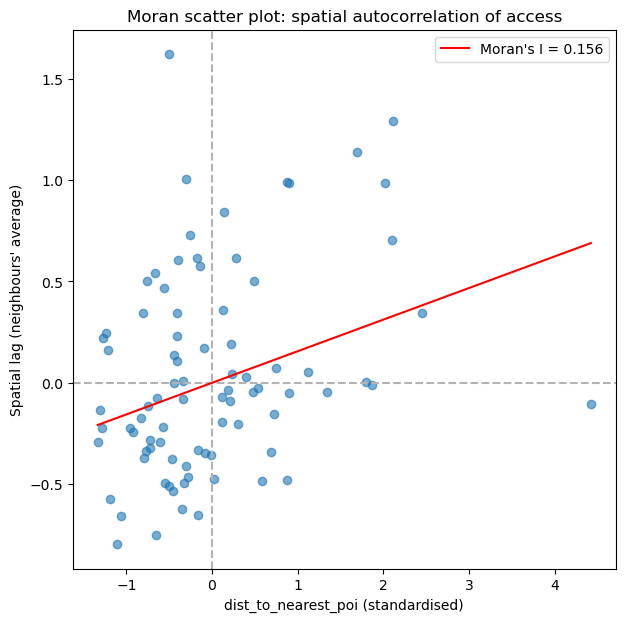

In [21]:
# Moran scatter plot
y_std = (y - y.mean()) / y.std()
y_lag = libpysal.weights.lag_spatial(w, y_std)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_std, y_lag, alpha=0.6)
ax.axhline(0, color="0.7", ls="--")
ax.axvline(0, color="0.7", ls="--")
b = np.polyfit(y_std, y_lag, 1)[0]
xs = np.linspace(y_std.min(), y_std.max(), 100)
ax.plot(xs, b * xs, color="red", label=f"Moran's I = {moran.I:.3f}")
ax.set_xlabel("dist_to_nearest_poi (standardised)")
ax.set_ylabel("Spatial lag (neighbours' average)")
ax.set_title("Moran scatter plot: spatial autocorrelation of access")
ax.legend()
plt.show()

As we can see from the plot above, there is a weak but real positive spatial autocorrelation in dist_to_nearest_poi (I=0.156, p=0.009). This indicates that neighbouring LSOAs do tend to have similar access to amenities, and that therefore inequality is spatially organised. Moreover, proximity clusters weakly because distance-to-nearest-POIs depends on a single point measured from each neighbourhood's centroid. For instance, suppose a cafe  sits within LSOA 1 but close to its border with LSOA 2, and it's the nearest POI to both LSOAs' centroids. The two still receive different access score because each distance is measured from a different centroid). So even neighbours sharing the same nearest amenity can get quite different scores - which explains the weakness in the spatial autocorrelation.

We can now check whether this pattern threatens the p-value of our distance model.


### 2nd Question

"Does the result of the first question threaten my p-value?"

Now that we know that there is a spatial autocorrelation, let's check if this threatens the reliability of our first model's p-value.

Let's remember that a p-value assumes the 84 LSOAs are independent observations. If the residuals still cluster in space, it means neighbouring LSOAs' errors move together - so the observations aren't independent, and the assumption the p-value relies on is broken. That would make our p-value overconfident.

residual = gap between what actually happened and what the model predicted (real value minus predicted value).

Residual Moran's I: 0.106
p-value:            0.049


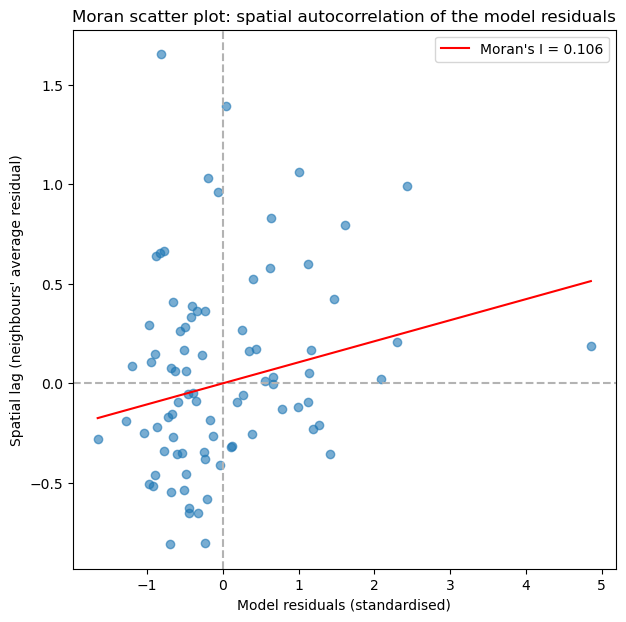

In [22]:
import numpy as np
from esda.moran import Moran

# 1. Fit the straight line behind the Pearson correlation:
#    predict distance-to-nearest-POI from distance-to-city-centre
x = gdf["dist_to_city_centre"].values
y = gdf["dist_to_nearest_poi"].values
# Finding the single straight line that best fits through the scattered points
slope, intercept = np.polyfit(x, y, 1)

# 2. Residuals = the part of access the city-centre model could NOT explain
residuals = y - (slope * x + intercept)

# 3. Moran's I on the residuals (seed makes the permutation p-value reproducible)
# Freezing randomnness to get same results when we re-run cell
np.random.seed(42)
# Shuffling residual values randomly across the map, recomputing moran's I 999 times,
# and comparing the actual Moran's I to that pile.
moran_resid = Moran(residuals, w, permutations=999)
print(f"Residual Moran's I: {moran_resid.I:.3f}")
print(f"p-value:            {moran_resid.p_sim:.3f}")

# 4. Moran scatter plot of the residuals
resid_std = (residuals - residuals.mean()) / residuals.std()
# For each LSOA, calculating the average residual of all of the 
# LSOAs bordering that LSOA
resid_lag = libpysal.weights.lag_spatial(w, resid_std)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(resid_std, resid_lag, alpha=0.6)
ax.axhline(0, color="0.7", ls="--")
ax.axvline(0, color="0.7", ls="--")
b = np.polyfit(resid_std, resid_lag, 1)[0]
xs = np.linspace(resid_std.min(), resid_std.max(), 100)
ax.plot(xs, b * xs, color="red", label=f"Moran's I = {moran_resid.I:.3f}")
ax.set_xlabel("Model residuals (standardised)")
ax.set_ylabel("Spatial lag (neighbours' average residual)")
ax.set_title("Moran scatter plot: spatial autocorrelation of the model residuals")
ax.legend()
plt.show()

We checked the model's residuals (the leftover error after predicting access from distance-to-centre). They showed weak, borderline-significant positive autocorrelation (I = 0.106, p ≈ 0.05). So some spatial structure remains in the errors even after the model.

Therefore, the monocentric model's p-value (p=0.003) is somewhat overconfident, because the 84 LSOAs aren't fully independent - neighbouring errors still cluster a little. However the effect is mild: the residual correlation is weak and only barely crosses significance, therefore the relationship itself is probably still real.  Distance-to-centre explains only a small slice of access (weak), and that small slice is probably a true effect rather than noise (real). 

Let's now try to plot amenities across a couple of cities in England and compare their distribution

# Multiple Cities Analysis

Preparing Birmingham ...
Preparing Oxford ...
Preparing Cambridge ...
Preparing Bristol ...
Preparing York ...
Preparing Manchester ...
Preparing Leeds ...


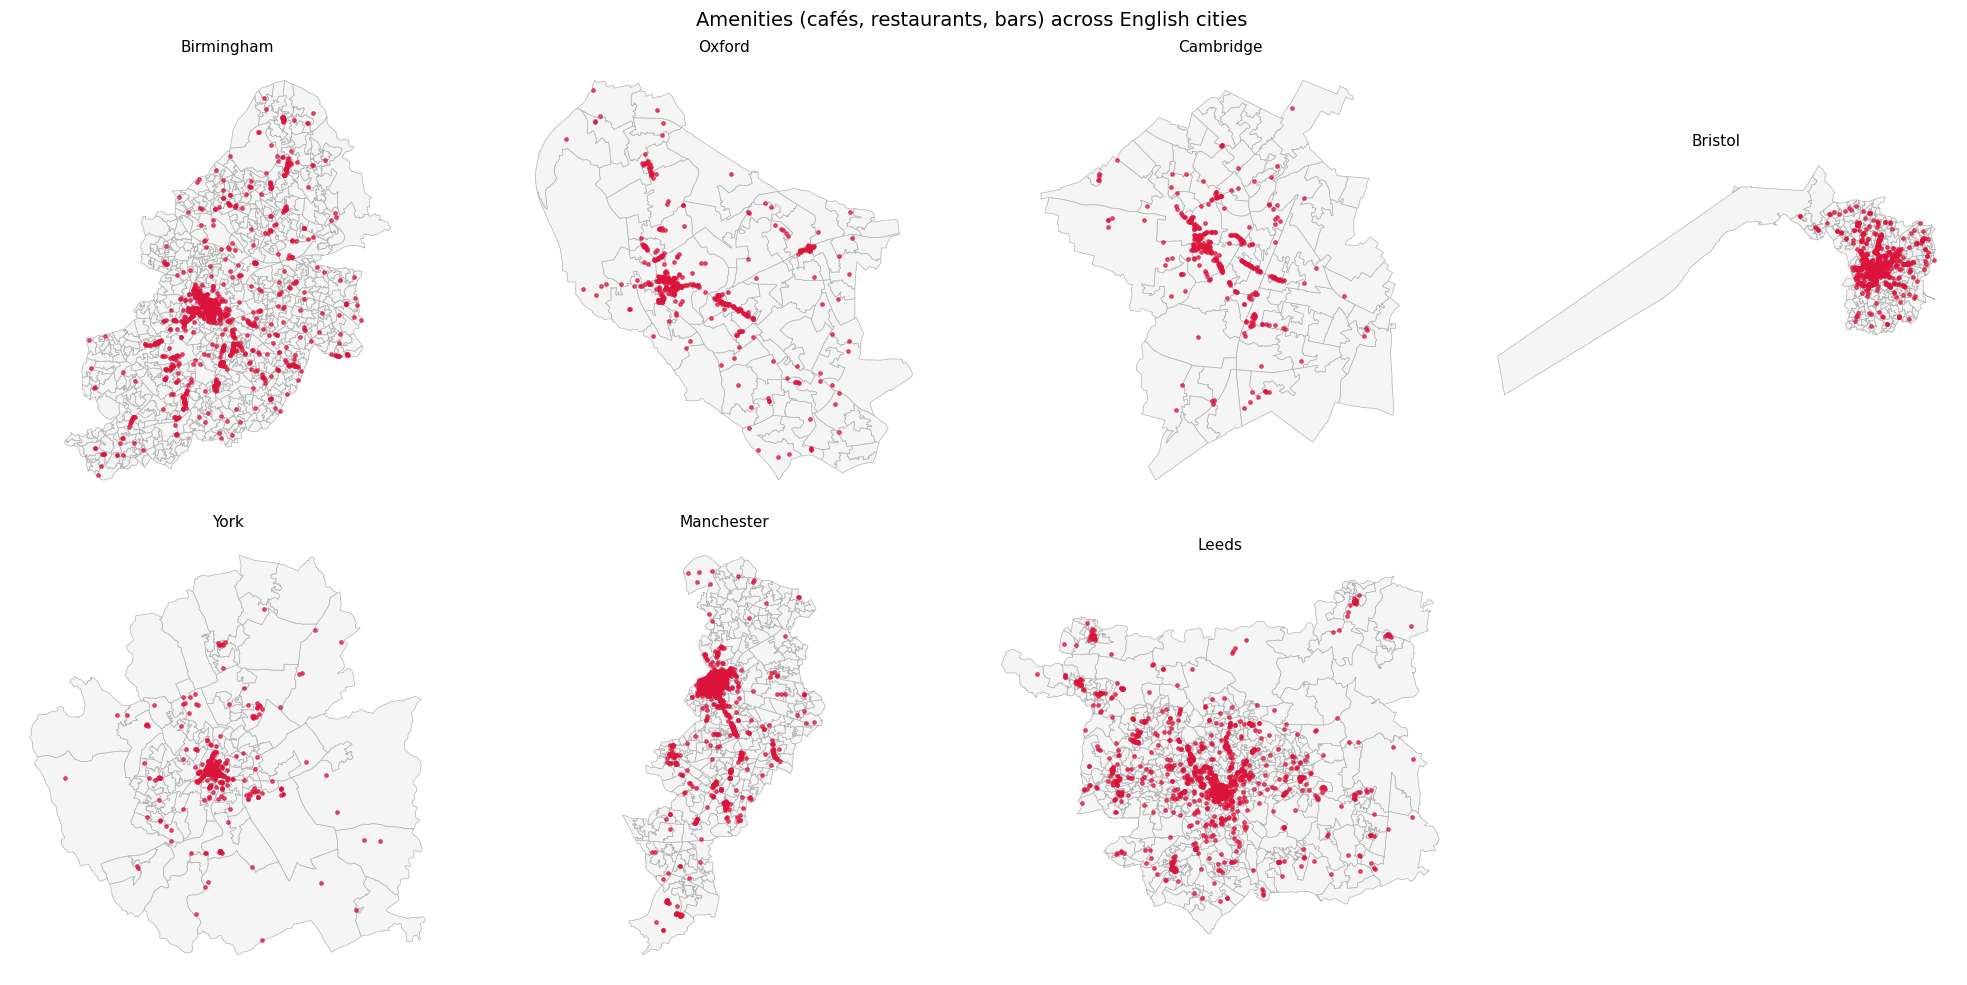

In [23]:
import math
import numpy as np
import osmnx as ox
import matplotlib.pyplot as plt

# --- Config: city -> (LSOA name prefix, OSM place query) ---
# LSOA names look like "Oxford 001A", so the city works as a name prefix.
# (startswith is fragile for shared prefixes like the two Newcastles, so keep
# this explicit and add ambiguous cities deliberately.)
CITY_LOOKUP = {
    "Birmingham": {"lsoa_prefix": "Birmingham", "osm_place": "Birmingham, England"},
    "Oxford":     {"lsoa_prefix": "Oxford",     "osm_place": "Oxford, England"},
    "Cambridge":  {"lsoa_prefix": "Cambridge",  "osm_place": "Cambridge, England"},
    "Bristol":    {"lsoa_prefix": "Bristol",    "osm_place": "Bristol, England"},
    "York":       {"lsoa_prefix": "York",       "osm_place": "York, England"},
    "Manchester": {"lsoa_prefix": "Manchester", "osm_place": "Manchester, England"},
    "Leeds":      {"lsoa_prefix": "Leeds",      "osm_place": "Leeds, England"},
}
CITIES = list(CITY_LOOKUP)
AMENITIES = {"amenity": ["cafe", "restaurant", "bar"]}


def prepare_city(city, lsoas_gdf, tags=AMENITIES):
    """Your Oxford/Cambridge block, parameterised by city.
    Returns (city_lsoas, city_pois), both in the LSOA CRS."""
    info = CITY_LOOKUP[city]

    # 1. LSOA polygons for this city
    city_lsoas = lsoas_gdf[
        lsoas_gdf["LSOA21NM"].str.startswith(info["lsoa_prefix"])
    ].copy()

    # 2. POIs from OpenStreetMap
    pois = ox.features_from_place(info["osm_place"], tags)

    # 3. Match the LSOA CRS, reduce each feature to one tidy point
    pois = pois.to_crs(city_lsoas.crs).copy()
    pois["geometry"] = pois.geometry.representative_point()

    return city_lsoas, pois


# --- Fetch once, cache (OSM downloads are the slow part) ---
city_data = {}
for city in CITIES:
    print(f"Preparing {city} ...")
    city_data[city] = prepare_city(city, lsoas_gdf)


# --- Plot every city as a panel in one grid ---
def plot_city_grid(city_data, ncols=4, figsize_per=(5, 5), suptitle=None):
    cities = list(city_data)
    n = len(cities)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows)
    )
    # Flatten so we can index linearly; also handles the 1x1 / single-row cases
    axes = np.array(axes).reshape(-1)

    for ax, city in zip(axes, cities):
        city_lsoas, pois = city_data[city]
        city_lsoas.plot(ax=ax, facecolor="whitesmoke", edgecolor="0.7", linewidth=0.5)
        pois.plot(ax=ax, markersize=6, alpha=0.7, color="crimson")
        ax.set_title(city, fontsize=11)
        ax.set_axis_off()
        ax.set_aspect("equal")

    # hide leftover empty panels (e.g. 8th cell for 7 cities in a 2x4 grid)
    for ax in axes[n:]:
        ax.set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_city_grid(
    city_data, ncols=4, suptitle="Amenities (cafés, restaurants, bars) across English cities"
)

At first glance, it looks like amenities are clustered somewhat around what seems to be their city centre. Birmingham and Leeds seem to have a higher concentration of amenities compared to cities such as York and Oxford, which have lots of empty neighbourhoods. However these cities might differ in size, therefore the higher number of amenities might be expected. Let's now check whether these cities relationship between distance to centre and distance to nearest POI follow a similar trend to Oxford's one.

H: "distance to centre is a good predictor across cities if a clear majority show a positive, statistically significant r." 

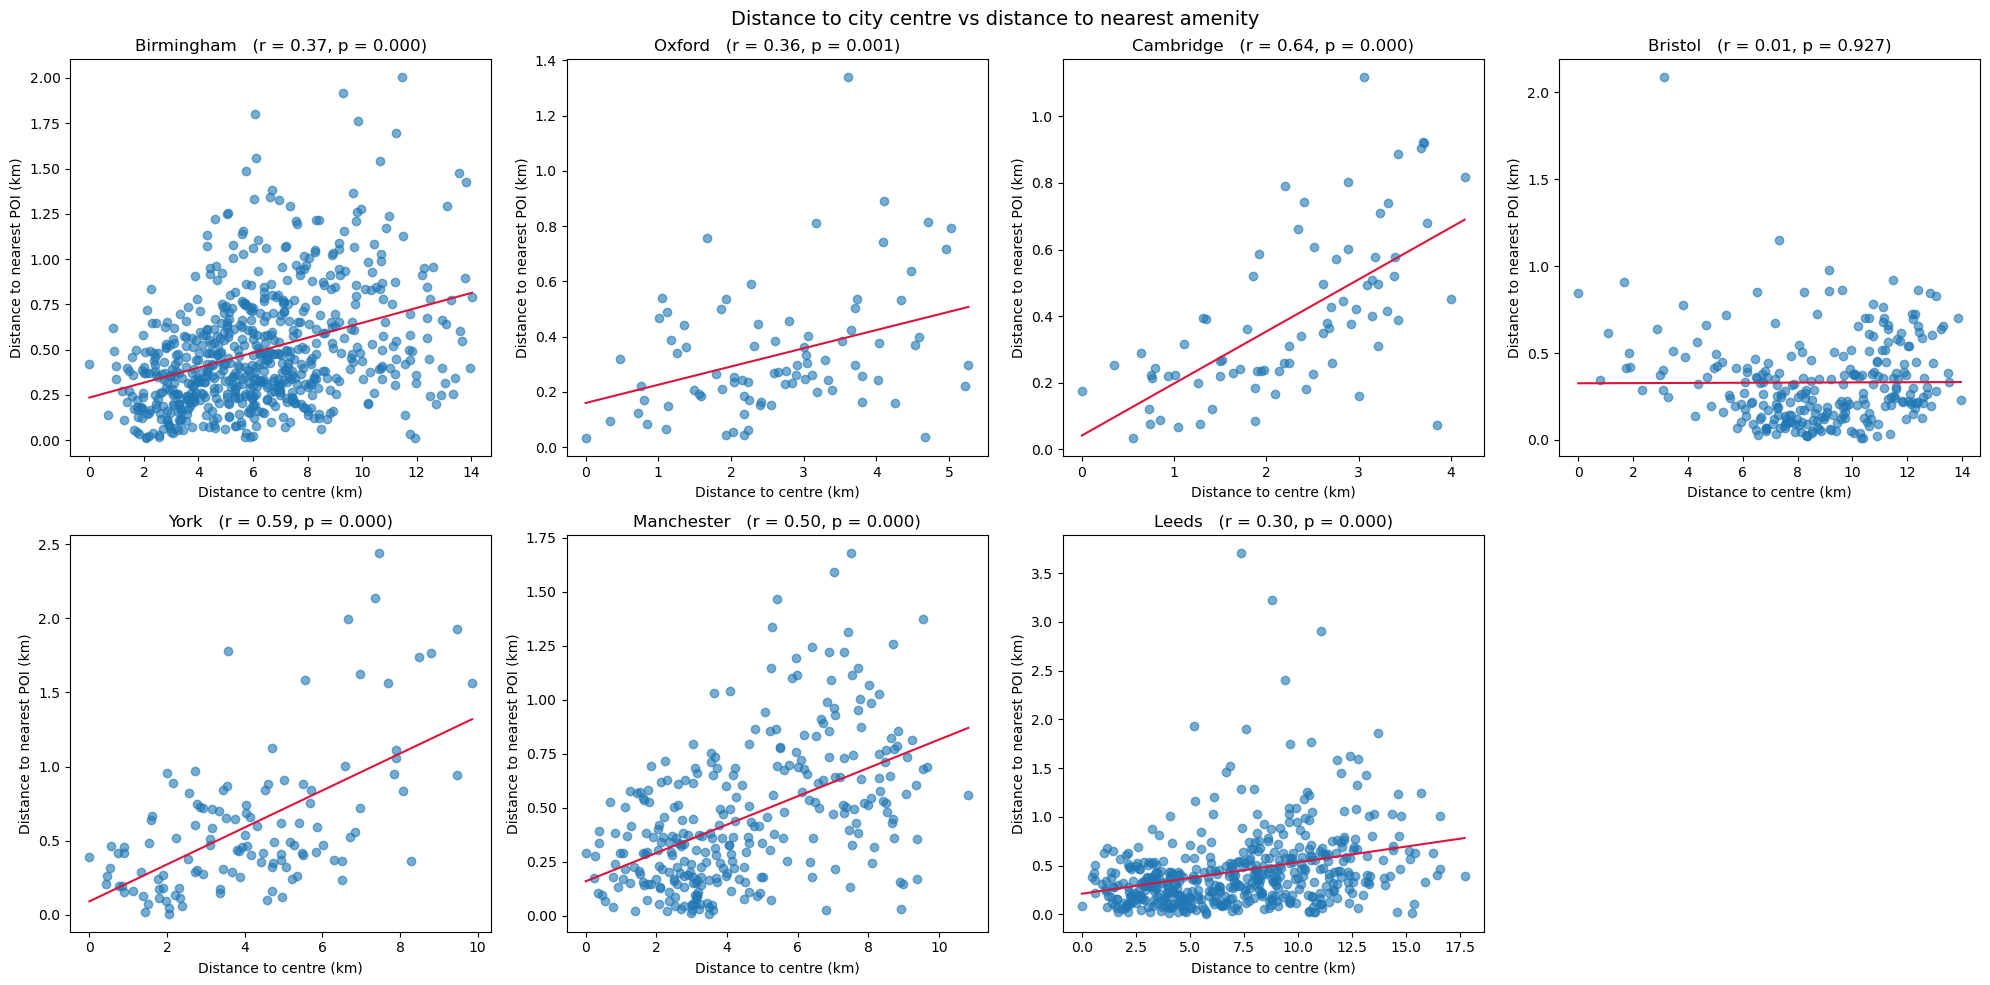

In [24]:
def city_centre(city_lsoas):
    """Centre = centroid of the most central neighbourhood
    (the LSOA whose centroid is nearest the city's geometric middle)."""
    mid = city_lsoas.geometry.union_all().centroid
    d2 = (city_lsoas.BNG_E - mid.x) ** 2 + (city_lsoas.BNG_N - mid.y) ** 2
    central = d2.idxmin()
    return city_lsoas.BNG_E.loc[central], city_lsoas.BNG_N.loc[central]


def centre_vs_access(city, lsoas_gdf):
    """For one city: distance from each LSOA to the centre, and to its nearest POI."""
    city_lsoas, pois = prepare_city(city, lsoas_gdf)   # your existing helper

    centroids = gpd.GeoDataFrame(
        city_lsoas[["LSOA21CD", "BNG_E", "BNG_N"]],
        geometry=gpd.points_from_xy(city_lsoas.BNG_E, city_lsoas.BNG_N),
        crs=27700,
    )
    near = centroids.sjoin_nearest(pois, distance_col="dist_to_nearest_poi")
    df = near[["BNG_E", "BNG_N", "dist_to_nearest_poi"]].drop_duplicates()

    cx, cy = city_centre(city_lsoas)
    df["dist_to_centre"] = ((df.BNG_E - cx) ** 2 + (df.BNG_N - cy) ** 2) ** 0.5
    return df


# --- One scatter panel per city ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for ax, city in zip(axes, CITIES):
    df = centre_vs_access(city, lsoas_gdf)
    r, p = stats.pearsonr(df["dist_to_centre"], df["dist_to_nearest_poi"])

    x = df["dist_to_centre"] / 1000          # km, for readability
    y = df["dist_to_nearest_poi"] / 1000

    ax.scatter(x, y, alpha=0.6)

    slope, intercept = np.polyfit(x, y, 1)   # best-fit line
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="crimson")

    ax.set_title(f"{city}   (r = {r:.2f}, p = {p:.3f})")
    ax.set_xlabel("Distance to centre (km)")
    ax.set_ylabel("Distance to nearest POI (km)")

# hide any leftover empty panels
for ax in axes[len(CITIES):]:
    ax.set_visible(False)

fig.suptitle(
    "Distance to city centre vs distance to nearest amenity", fontsize=14
)
fig.tight_layout()
plt.show()

The trend is somewhat linear, with some cities having a stronger relationship (Cambridge, York, Manchester) and some others a weaker one (Birmingham, Oxford, Leeds). Moreover, Bristol's relationship seems to be quite weak, almost non-existent. I suspect this is due to the city centre's centroid not being calculated properly. This stems from that extra piece of land on the left-hand side of Bristol's map, which is completely empty from amenities. I suspect that that has skewed the calculation of the city centre. Let's check.

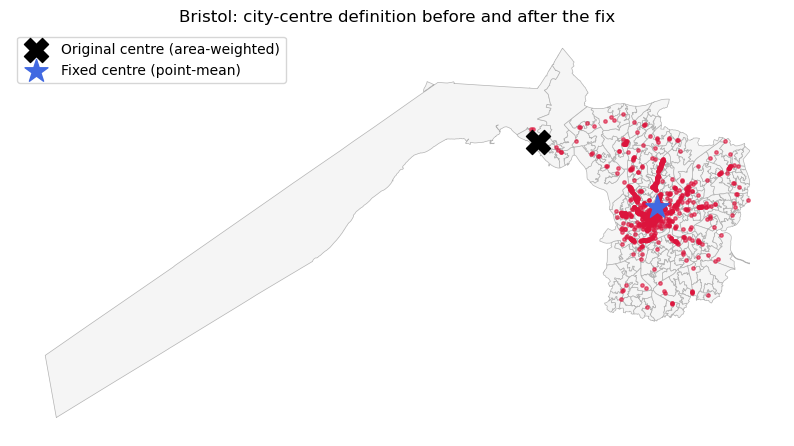

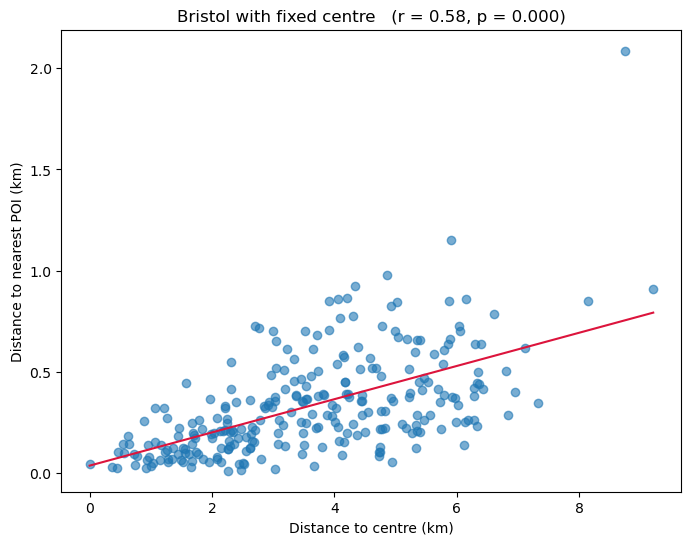

In [25]:
# --- Fixed centre: nearest LSOA to the MEAN of LSOA centroids ---
# Averaging points (not polygon area) keeps the centre in the populated
# core and ignores large, empty boundary appendages (Bristol's NW strip).
def city_centre_pointmean(city_lsoas):
    mid_x = city_lsoas.BNG_E.mean()
    mid_y = city_lsoas.BNG_N.mean()
    d2 = (city_lsoas.BNG_E - mid_x) ** 2 + (city_lsoas.BNG_N - mid_y) ** 2
    central = d2.idxmin()
    return city_lsoas.BNG_E.loc[central], city_lsoas.BNG_N.loc[central]


# --- Distance-to-centre vs distance-to-nearest-POI, with a swappable centre ---
def centre_vs_access(city, lsoas_gdf, centre_fn=city_centre):
    city_lsoas, pois = prepare_city(city, lsoas_gdf)
    centroids = gpd.GeoDataFrame(
        city_lsoas[["LSOA21CD", "BNG_E", "BNG_N"]],
        geometry=gpd.points_from_xy(city_lsoas.BNG_E, city_lsoas.BNG_N),
        crs=27700,
    )
    near = centroids.sjoin_nearest(pois, distance_col="dist_to_nearest_poi")
    df = near[["BNG_E", "BNG_N", "dist_to_nearest_poi"]].drop_duplicates()
    cx, cy = centre_fn(city_lsoas)
    df["dist_to_centre"] = ((df.BNG_E - cx) ** 2 + (df.BNG_N - cy) ** 2) ** 0.5
    return df


# --- Prepare Bristol once, compute both centres ---
bristol_lsoas, bristol_pois = prepare_city("Bristol", lsoas_gdf)
old_cx, old_cy = city_centre(bristol_lsoas)            # area-weighted (original)
new_cx, new_cy = city_centre_pointmean(bristol_lsoas)  # point-mean (fixed)


# --- 1. Map: original vs fixed centre ---
fig, ax = plt.subplots(figsize=(10, 10))
bristol_lsoas.plot(ax=ax, facecolor="whitesmoke", edgecolor="0.7", linewidth=0.5)
bristol_pois.plot(ax=ax, markersize=6, alpha=0.6, color="crimson")
ax.scatter(old_cx, old_cy, s=300, marker="X", color="black",
           label="Original centre (area-weighted)", zorder=5)
ax.scatter(new_cx, new_cy, s=300, marker="*", color="royalblue",
           label="Fixed centre (point-mean)", zorder=5)
ax.set_title("Bristol: city-centre definition before and after the fix")
ax.set_axis_off()
ax.legend(loc="upper left")
plt.show()


# --- 2. Scatter: distance to centre vs nearest POI, using the fixed centre ---
bristol_fixed = centre_vs_access("Bristol", lsoas_gdf, centre_fn=city_centre_pointmean)
r, p = stats.pearsonr(
    bristol_fixed["dist_to_centre"], bristol_fixed["dist_to_nearest_poi"]
)

fig, ax = plt.subplots(figsize=(8, 6))
x = bristol_fixed["dist_to_centre"] / 1000   # km
y = bristol_fixed["dist_to_nearest_poi"] / 1000
ax.scatter(x, y, alpha=0.6)
slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="crimson")
ax.set_title(f"Bristol with fixed centre   (r = {r:.2f}, p = {p:.3f})")
ax.set_xlabel("Distance to centre (km)")
ax.set_ylabel("Distance to nearest POI (km)")
plt.show()

It was indeed because of that. In the previous plots, we were using an area-weighted polygon centroid, which means that we merged all LSOAs polygons into one big shape and took the centroid of that, which is weighted by land area. In that case, every square metre of the city counts equally, which means that a large region without any amenities would pull the cetroid to itself, which is what happened with Bristol's Avonmouth. Whereas now we are using the mean of the LSOA centroid points. We gave one point per neighbourhood, regardless of how big or small the neighbourhood is, and that point is the population-weighted centroid. The centre lands wherever the neighbourhoods are densest. 

In our analysis, we quickly spotted Bristol as the left-out city as it was obvious that something was going on. This was evident from the comparison we made between its amenities map and its scatter plot. Clearly, in the map we could see that the amenities were clustered in the centre, but the scatter plot was suggesting otherwise. Let's now try to apply the population-weighted function to all cities, in case there's another discrepancy in the calculation of the city centre's centroid that we cannot spot on our own.

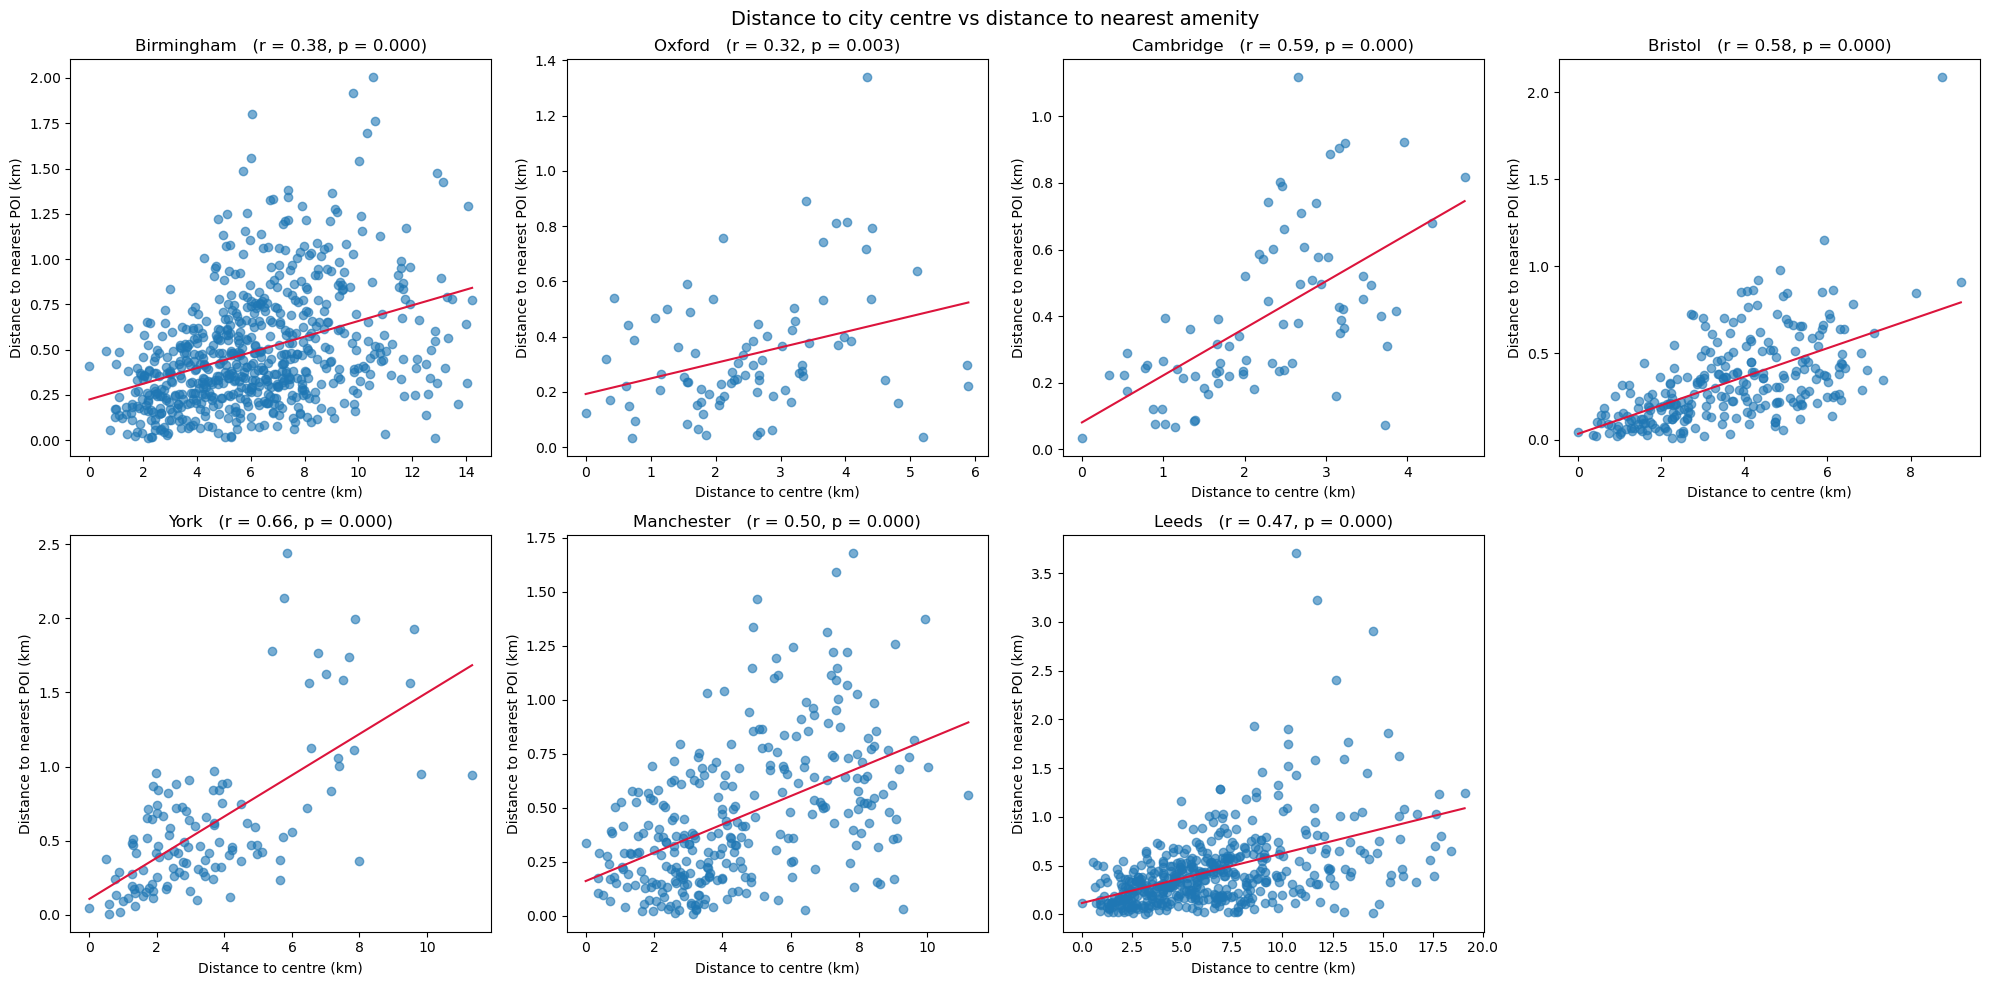

In [26]:
# --- Fixed centre: nearest LSOA to the MEAN of LSOA centroids ---
# Averaging points (not polygon area) keeps the centre in the populated
# core and ignores large, empty boundary appendages (Bristol's NW strip).
#def city_centre_pointmean(city_lsoas):
#    mid_x = city_lsoas.BNG_E.mean()
#    mid_y = city_lsoas.BNG_N.mean()
#    d2 = (city_lsoas.BNG_E - mid_x) ** 2 + (city_lsoas.BNG_N - mid_y) ** 2
#    central = d2.idxmin()
#    return# city_lsoas.BNG_E.loc[central], city_lsoas.BNG_N.loc[central]

def merge_city_data_with_population_data(city_name):
    # Filter to Oxford
    city_pop_df = pop_df[pop_df["LAD 2023 Name"] == city_name].copy()
    
    # Rename columns to make them match with other dataframes and to make them more explicative
    city_pop_df = city_pop_df.rename(
        columns={"LSOA 2021 Code": "LSOA21CD", "Total": "population"}
    )
    merged_df = city_df.merge(
    city_pop_df[['LSOA21CD', 'population']],
    on="LSOA21CD", 
    how="left"
    )
    return merged_df
    

def population_weighted_centroid(merged_df):
    tot_pop = merged_df['population'].sum()
    centroid_x_axis = np.sum((merged_df['BNG_E'] * merged_df['population']) / tot_pop)
    centroid_y_axis = np.sum((merged_df['BNG_N'] * merged_df['population']) / tot_pop)
    fig, ax = plt.subplots(figsize=(10, 10))
    merged_df.plot(ax=ax, facecolor="whitesmoke", edgecolor="0.7", linewidth=0.5)
    merged_df.plot(ax=ax, markersize=6, alpha=0.6)
    ax.scatter(centroid_x_axis, centroid_y_axis, s=300, marker="*", color="royalblue",
               label="Population-weighted centre", zorder=5)
    ax.set_title(f"{city_name}: population-weighted centroid")
    ax.set_axis_off()
    ax.legend(loc="upper left")
    plt.show()
    return centroid_x_axis, centroid_y_axis



def centre_vs_access(city, lsoas_gdf):
    """For one city: distance from each LSOA to the centre, and to its nearest POI."""
    city_lsoas, pois = prepare_city(city, lsoas_gdf)   # your existing helper

    centroids = gpd.GeoDataFrame(
        city_lsoas[["LSOA21CD", "BNG_E", "BNG_N"]],
        geometry=gpd.points_from_xy(city_lsoas.BNG_E, city_lsoas.BNG_N),
        crs=27700,
    )
    near = centroids.sjoin_nearest(pois, distance_col="dist_to_nearest_poi")
    df = near[["BNG_E", "BNG_N", "dist_to_nearest_poi"]].drop_duplicates()

    cx, cy = city_centre_pointmean(city_lsoas)
    df["dist_to_centre"] = ((df.BNG_E - cx) ** 2 + (df.BNG_N - cy) ** 2) ** 0.5
    return df


# --- One scatter panel per city ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for ax, city in zip(axes, CITIES):
    df = centre_vs_access(city, lsoas_gdf)
    r, p = stats.pearsonr(df["dist_to_centre"], df["dist_to_nearest_poi"])

    x = df["dist_to_centre"] / 1000          # km, for readability
    y = df["dist_to_nearest_poi"] / 1000

    ax.scatter(x, y, alpha=0.6)

    slope, intercept = np.polyfit(x, y, 1)   # best-fit line
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="crimson")

    ax.set_title(f"{city}   (r = {r:.2f}, p = {p:.3f})")
    ax.set_xlabel("Distance to centre (km)")
    ax.set_ylabel("Distance to nearest POI (km)")

# hide any leftover empty panels
for ax in axes[len(CITIES):]:
    ax.set_visible(False)

fig.suptitle(
    "Distance to city centre vs distance to nearest amenity", fontsize=14
)
fig.tight_layout()
plt.show()

All rs got a higher score, except for Oxford and Cambridge which got a slightly lower score, and Manchester whose score stayed the same.
This shows that distance to centre is a somewhat good predictor across cities since a clear majority show a positive r. However, let's now explore where this positivity is statistically significant.

Inspecting the way the city centre centroid is calculated and check if correct.

Previous method:
- find the union of all LSOAs with union all method -> centroid
- for each LSOA, find their centroid
- extract the LSOA whose centroid is the nearest to the city's geometric middle

Second method:
- finding the average all centroids' points (not polygon area)
- applying the distance formula (subtracting the avg centroid to each LSOA's centroid coordinate 1, squaring it, then summing it to their coordinate 2 equivalent)
- finding the point with the lowest distance from the average centroid.

In Oxford, we found the centroid by hardcoding the coordinates of a specific point: Carfax Tower. It was not sustainable to do this for all cities, hence why we are calculating the centroid from scratch.

It would still be good to calculate a population-weighted centroid, since it's more relevant to consider the experience of more people rather than of few.

In [27]:
# Extract Oxford city's data and POI's data
oxford_df, oxford_pois_df = prepare_city("Oxford", lsoas_gdf)

# Extract estimated mid-2024 population for each 2021-defined LSOA
pop_df = pd.read_excel(
    r"sapelsoasyoa20222024.xlsx",
    sheet_name="Mid-2024 LSOA 2021",
    header=[3],
)

# Filter to Oxford
oxford_pop_df = pop_df[pop_df["LAD 2023 Name"] == "Oxford"].copy()

# Rename columns to make them match with other dataframes and to make them more explicative
oxford_pop_df = oxford_pop_df.rename(
    columns={"LSOA 2021 Code": "LSOA21CD", "Total": "population"}
)

# Explore population per LSOA of Oxford
oxford_pop_df.head(2)

,LAD 2023 Code,LAD 2023 Name,LSOA21CD,LSOA 2021 Name,population,F0,F1,F2,F3,F4,...,M81,M82,M83,M84,M85,M86,M87,M88,M89,M90
17837,E07000178,Oxford,E01028513,Oxford 005A,2732,20,24,10,23,22,...,9,8,4,2,0,0,1,3,0,3
17838,E07000178,Oxford,E01028514,Oxford 005B,1558,1,2,6,3,7,...,4,3,1,5,0,0,2,0,0,2


In [28]:
# Merging Oxford city data with Oxford population data
oxford_merged_df = oxford_df.merge(
    oxford_pop_df[['LSOA21CD', 'population']],
    on="LSOA21CD", 
    how="left"
)

# Finding Oxford total population
tot_pop = oxford_merged_df['population'].sum()

# Calculating the Easting and Northing coordinates of the city centre's centroid 
centroid_BNG_E = np.sum((oxford_merged_df['BNG_E'] * oxford_merged_df['population']) / tot_pop)
centroid_BNG_N = np.sum((oxford_merged_df['BNG_N'] * oxford_merged_df['population']) / tot_pop)

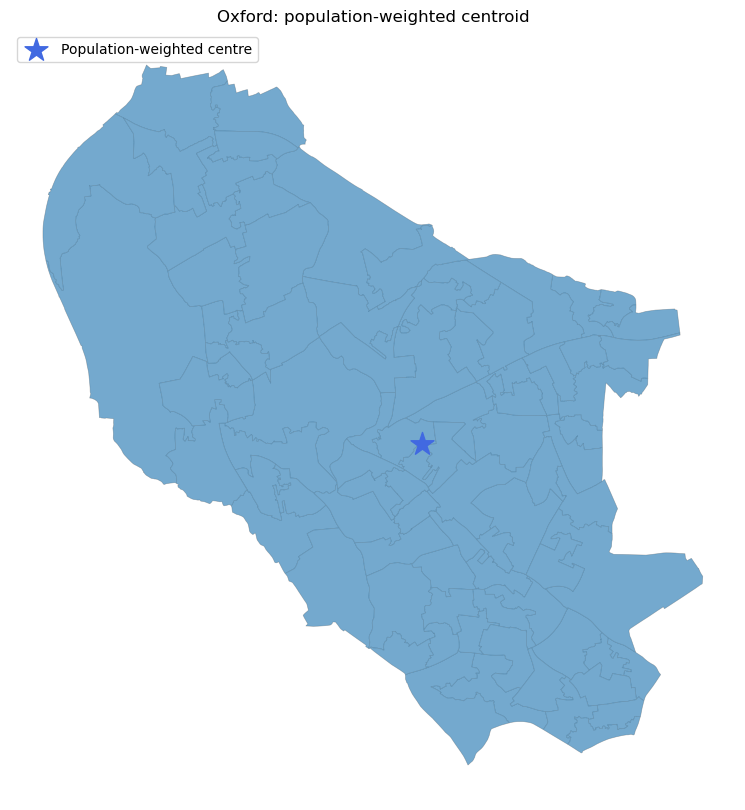

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))
oxford_merged_df.plot(ax=ax, facecolor="whitesmoke", edgecolor="0.7", linewidth=0.5)
oxford_merged_df.plot(ax=ax, markersize=6, alpha=0.6)
ax.scatter(centroid_BNG_E, centroid_BNG_N, s=300, marker="*", color="royalblue",
           label="Population-weighted centre", zorder=5)
ax.set_title("Oxford: population-weighted centroid")
ax.set_axis_off()
ax.legend(loc="upper left")
plt.show()

We calculated the population-weighted centroid of Oxford. It pulls east/southeast toward dense residential areas, such as East Oxford, Cowley, and Headington. Our previous centroid, Carfax Tower, was in an under-populated historic core area, and closer to green spaces such as Port Meadow, University PArks, and Christ Church Meadow.

Next steps: re-calculate the centroid for all cities and perform the analysis again with the new centroid. Make a comparison of old centroid vs new centroid to see how much they differ.

### Provision - Population and Amenities

### 1. Count POIs per neighbourhood using a spatial join

In [30]:
# Join each POI to the LSOA it falls within
pois_in_lsoas_df = gpd.sjoin(
    oxford_pois_reprojected,
    oxford_lsoas_gdf[["LSOA21CD", "geometry"]],
    how="inner",
    predicate="within",
)
pois_in_lsoas_df.head(2)

geometry addr:city addr:housenumber  \
element id                                                                    
node    231413379  POINT (451076.794 206437.902)    Oxford          100-101   
        251232416  POINT (451006.802 206459.039)    Oxford              NaN   

                  addr:postcode       addr:street     amenity breakfast  \
element id                                                                
node    231413379       OX1 2DF  Gloucester Green  restaurant        no   
        251232416       OX1 2BU  Gloucester Green  restaurant        no   

                   check_date                              contact:facebook  \
element id                                                                    
node    231413379  2025-06-15    https://www.facebook.com/100percent.pasta/   
        251232416  2025-06-15  https://www.facebook.com/Sichuangrandlondon/   

                                               contact:instagram  ...  \
element id                                                        ...   
node    231413379    https://www.instagram.com/100percent.pasta/  ...   
        251232416  https://www.instagram.com/sichuangrand/?hl=en  ...   

                  building:colour building:material opening_date landuse  \
element id                                                                 
node    231413379             NaN               NaN          NaN     NaN   
        251232416             NaN               NaN          NaN     NaN   

                  start_date food:meal food:sandwich cluster index_right  \
element id                                                                 
node    231413379        NaN       NaN           NaN       1       27075   
        251232416        NaN       NaN           NaN       1       27075   

                    LSOA21CD  
element id                    
node    231413379  E01028521  
        251232416  E01028521  

[2 rows x 180 columns]

In [31]:
# Count how many POIs landed in each LSOA
poi_counts = (
    pois_in_lsoas_df.groupby("LSOA21CD").size().reset_index(name="poi_count")
)
poi_counts.head(2)

,LSOA21CD,poi_count
0,E01028513,1
1,E01028516,1


### 2. Merge with population and compute per-capita

In [32]:
# Extract estimated mid-2024 population for each 2021-defined LSOA
pop_df = pd.read_excel(
    r"sapelsoasyoa20222024.xlsx",
    sheet_name="Mid-2024 LSOA 2021",
    header=[3],
)

# Filter to Oxford
pop_df = pop_df[pop_df["LAD 2023 Name"] == "Oxford"].copy()

# Rename columns to make them match with other dataframes and to make them more explicative
pop_df = pop_df.rename(
    columns={"LSOA 2021 Code": "LSOA21CD", "Total": "population"}
)

# Explore population per LSOA of Oxford
pop_df.head(2)

,LAD 2023 Code,LAD 2023 Name,LSOA21CD,LSOA 2021 Name,population,F0,F1,F2,F3,F4,...,M81,M82,M83,M84,M85,M86,M87,M88,M89,M90
17837,E07000178,Oxford,E01028513,Oxford 005A,2732,20,24,10,23,22,...,9,8,4,2,0,0,1,3,0,3
17838,E07000178,Oxford,E01028514,Oxford 005B,1558,1,2,6,3,7,...,4,3,1,5,0,0,2,0,0,2


In [33]:
# Add population to the access dataframe
oxf_access_df = oxf_access_df.merge(
    pop_df[["LSOA21CD", "population"]], on="LSOA21CD", how="left"
)

# Add POI counts (LSOAs with no POIs get 0)
oxf_access_df = oxf_access_df.merge(poi_counts, on="LSOA21CD", how="left")
oxf_access_df["poi_count"] = oxf_access_df["poi_count"].fillna(0).astype(int)

# Per-capita measure
oxf_access_df["pois_per_1000"] = oxf_access_df["poi_count"] / oxf_access_df["population"] * 1000

oxf_access_df.head(2)

,LSOA21CD,BNG_E,BNG_N,dist_to_nearest_poi,dist_to_city_centre,dist_to_nearest_cluster_centre,nearest_cluster,population,poi_count,pois_per_1000
0,E01028513,455386,207847,207.056247,4408.548514,1127.213970,3,2732,1,0.366032
1,E01028514,455784,207805,296.396058,4764.752669,1451.216062,3,1558,0,0.000000


### Visualize the distribution

<Axes: ylabel='Frequency'>

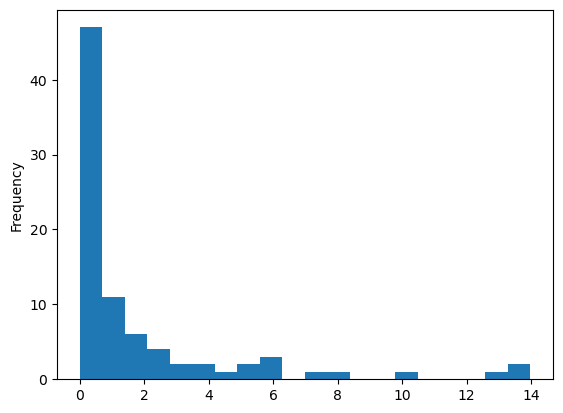

In [34]:
oxf_access_df["pois_per_1000"].plot.hist(bins=20)

### Map it

<Axes: >

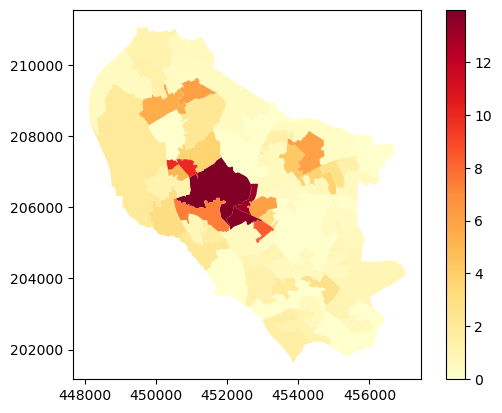

In [35]:
oxford_lsoas_gdf.merge(oxf_access_df, on="LSOA21CD").plot(
    column="pois_per_1000", cmap="YlOrRd", legend=True
)

In [36]:
max_rate = oxf_access_df["pois_per_1000"].max()
median_rate = oxf_access_df["pois_per_1000"].median()
x_times = max_rate / median_rate
n_zero = (oxf_access_df["poi_count"] == 0).sum()

print(f"[max]    = {max_rate:.1f} venues per 1,000 residents")
print(f"[median] = {median_rate:.2f} venues per 1,000 residents")
print(f"[X]      = {x_times:.0f} times the citywide median")
print(f"[N]      = {n_zero} LSOAs with no venues")

[max]    = 14.0 venues per 1,000 residents
[median] = 0.60 venues per 1,000 residents
[X]      = 23 times the citywide median
[N]      = 25 LSOAs with no venues


Amenities are unequally distributed across Oxford's LSOAs even relative to population. As the map shows, the central neighbourhood has around 14 venues per 1,000 residents — roughly 23 times the citywide median of 0.6 — and 25 LSOAs, almost a third of the city and mostly on its periphery, contain no venues at all. Provision is therefore heavily concentrated in the centre, though this measure reflects where venues are rather than precisely how easily each resident can reach them.

# Cambridge

In [37]:
# Get Cambridge's LSOAs data
cambridge_lsoas_gdf = lsoas_gdf[lsoas_gdf['LSOA21NM'].str.startswith('Cambridge')].copy()
cambridge_lsoas_gdf.head(2)

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
17031,E01017943,Cambridge 006A,,546533,259100,52.210659,0.143228,{D9D54E97-1FC2-482B-B84A-08917EA4E8CC},"MULTIPOLYGON (((546675.969 259573.13, 546676.3..."
17032,E01017944,Cambridge 006B,,548008,259806,52.216599,0.165108,{07CD5906-5586-4928-8FED-3A9E166AE872},"MULTIPOLYGON (((547905.245 260087.649, 547902...."


In [38]:
# Download points of interests in Cambridge
cambridge_pois_df = ox.features_from_place(
    "Cambridge, England", {"amenity": ["cafe", "restaurant", "bar"]}
)

# Reproject POIs so that they have the same CRS as the LSOA dataframe
cambridge_pois_reprojected = cambridge_pois_df.to_crs(cambridge_lsoas_gdf.crs).copy()

# one tidy point per POI
cambridge_pois_reprojected["geometry"] = (
    cambridge_pois_reprojected.geometry.representative_point()
)  

cambridge_pois_reprojected.head(2)

geometry  addr:city     addr:county  \
element id                                                                   
node    20823646  POINT (545392.935 258173.121)  Cambridge  Cambridgeshire   
        20824011  POINT (545515.017 259232.104)  Cambridge             NaN   

                 addr:postcode      addr:street   alt_name     amenity  \
element id                                                               
node    20823646       CB1 1JH     Park Terrace  Baan Thai  restaurant   
        20824011       CB4 1HA  Victoria Avenue        NaN  restaurant   

                 cuisine  fhrs:id                              name  ...  \
element id                                                           ...   
node    20823646    thai  1473092  Baan Thai Street Food Restaurant  ...   
        20824011     NaN  1472531                   Midsummer House  ...   

                 disused:shop loc_name music note:real_ale ref_1  \
element id                                                         
node    20823646          NaN      NaN   NaN           NaN   NaN   
        20824011          NaN      NaN   NaN           NaN   NaN   

                 diet:non-vegetarian diet:gluten_free floor:material  \
element id                                                             
node    20823646                 NaN              NaN            NaN   
        20824011                 NaN              NaN            NaN   

                 addr:village type  
element id                          
node    20823646          NaN  NaN  
        20824011          NaN  NaN  

[2 rows x 133 columns]

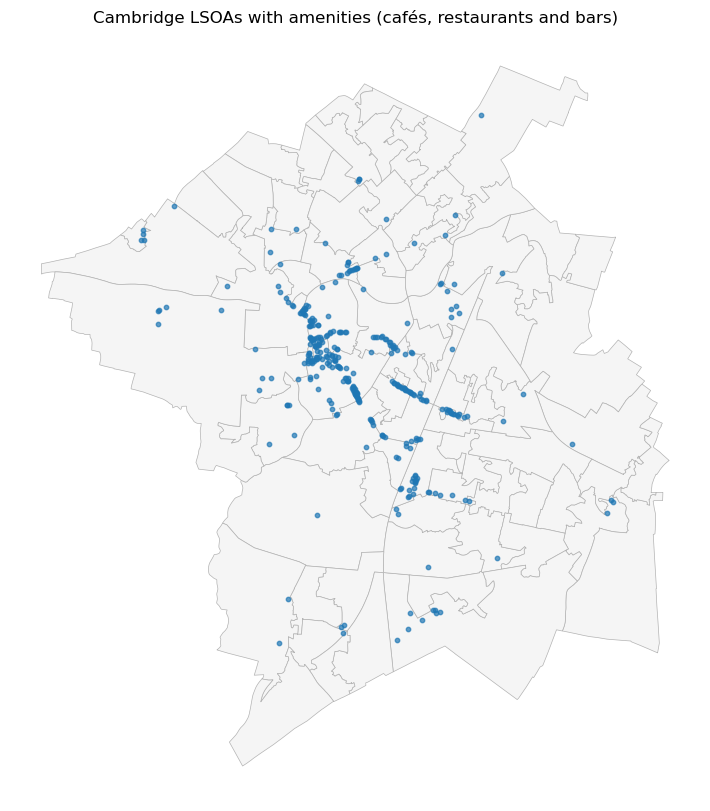

In [39]:
# Plotting amenities across LSOAs in Cambridge
fig, ax = plt.subplots(figsize=(10, 10))

# base: the neighbourhoods
cambridge_lsoas_gdf.plot(ax=ax, facecolor="whitesmoke", edgecolor="0.7", linewidth=0.5)

# overlay: the POIs
cambridge_pois_reprojected.plot(
    ax=ax, markersize=10, alpha=0.7, legend=True
)

ax.set_title("Cambridge LSOAs with amenities (cafés, restaurants and bars)")
ax.set_axis_off()
plt.show()

The amenities in Cambridge are somewhat clustered towards the city centre. However there are also some other hubs sparse around the city, such as Mill Road and Chesterton Road. Let's explore the relationship between the neighbourhoods' centroids and their nearest POI.

In [40]:
# Build a dataframe of centroids for each LSOA
cambridge_centroids_gdf = gpd.GeoDataFrame(
    cambridge_lsoas_gdf[["LSOA21CD"]],
    geometry=gpd.points_from_xy(cambridge_lsoas_gdf.BNG_E, cambridge_lsoas_gdf.BNG_N), # using British National Grid Easting 
    # and Northing coordinates
    crs=27700,
)
cambridge_centroids_gdf.head(2)

,LSOA21CD,geometry
17031,E01017943,POINT (546533 259100)
17032,E01017944,POINT (548008 259806)


In [41]:
# Reproject POIs to BNG so both layers are in the same CRS
cambridge_pois_bng = cambridge_pois_df.to_crs(27700).copy()
cambridge_pois_bng["geometry"] = cambridge_pois_bng.geometry.representative_point()
cambridge_pois_bng.head(2)

geometry  addr:city     addr:county  \
element id                                                                   
node    20823646  POINT (545392.935 258173.121)  Cambridge  Cambridgeshire   
        20824011  POINT (545515.017 259232.104)  Cambridge             NaN   

                 addr:postcode      addr:street   alt_name     amenity  \
element id                                                               
node    20823646       CB1 1JH     Park Terrace  Baan Thai  restaurant   
        20824011       CB4 1HA  Victoria Avenue        NaN  restaurant   

                 cuisine  fhrs:id                              name  ...  \
element id                                                           ...   
node    20823646    thai  1473092  Baan Thai Street Food Restaurant  ...   
        20824011     NaN  1472531                   Midsummer House  ...   

                 disused:shop loc_name music note:real_ale ref_1  \
element id                                                         
node    20823646          NaN      NaN   NaN           NaN   NaN   
        20824011          NaN      NaN   NaN           NaN   NaN   

                 diet:non-vegetarian diet:gluten_free floor:material  \
element id                                                             
node    20823646                 NaN              NaN            NaN   
        20824011                 NaN              NaN            NaN   

                 addr:village type  
element id                          
node    20823646          NaN  NaN  
        20824011          NaN  NaN  

[2 rows x 133 columns]

In [42]:
# For every centroid, find nearest POI across all POIs
cambridge_centroids_and_pois_gdf = cambridge_centroids_gdf.sjoin_nearest(
    cambridge_pois_bng, distance_col="dist_to_nearest_poi"
)
cambridge_access_scores_df = cambridge_centroids_and_pois_gdf[["LSOA21CD", "dist_to_nearest_poi"]]
cambridge_access_scores_df.head(2)

,LSOA21CD,dist_to_nearest_poi
17031,E01017943,121.702805
17032,E01017944,803.112425


In [43]:
# Hardcode the coordinates of the city centre of Cambridge (Market Hill), EPSG:27700
cx, cy = 544925, 258507

# Merge access scores with the LSOA coordinates
cambridge_access_df = cambridge_lsoas_gdf[["LSOA21CD", "BNG_E", "BNG_N"]].merge(
    cambridge_access_scores_df, on="LSOA21CD"
)

# Calculate the distance from the centroid of each LSOA to the city centre
cambridge_access_df["dist_to_city_centre"] = (
    (cambridge_access_df.BNG_E - cx) ** 2 + (cambridge_access_df.BNG_N - cy) ** 2
) ** 0.5

cambridge_access_df.head(2)

,LSOA21CD,BNG_E,BNG_N,dist_to_nearest_poi,dist_to_city_centre
0,E01017943,546533,259100,121.702805,1713.859096
1,E01017944,548008,259806,803.112425,3345.488006


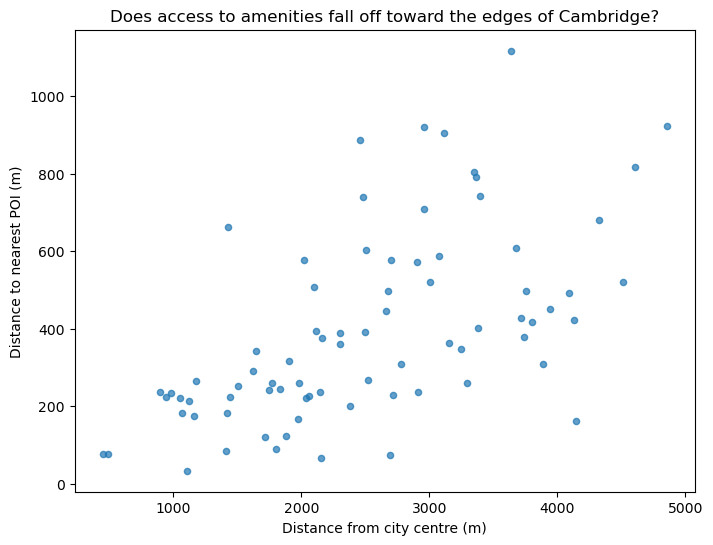

In [44]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
cambridge_access_df.plot.scatter(
    ax=ax, x="dist_to_city_centre", y="dist_to_nearest_poi", alpha=0.7
)
ax.set_xlabel("Distance from city centre (m)")
ax.set_ylabel("Distance to nearest POI (m)")
ax.set_title("Does access to amenities fall off toward the edges of Cambridge?")
plt.show()

In [45]:
# Computing Pearson coefficient and p-value to check the strength of the relationship
cambridge_r, cambridge_p = stats.pearsonr(
    cambridge_access_df["dist_to_city_centre"], cambridge_access_df["dist_to_nearest_poi"]
)
print(f"r = {cambridge_r:.2f},  p = {cambridge_p:.3f}")

r = 0.59,  p = 0.000


There is a strong relationship between the distance from the city centre and the distance to the nearest POIs. This means that, the further away a neighbourhood is from the centre, the reduced access they have to amenities in Cambridge. This Pearson coefficient (r=0.59) is stronger than the one of the Oxford (r=0.32), which is an interesting result.

In [46]:
# Cluster POIs to find the cluster centres
cambridge_coords = np.column_stack([cambridge_pois_reprojected.geometry.x, cambridge_pois_reprojected.geometry.y])

# Fit K-means to find 5 amenity clusters 
cambridge_kmeans = KMeans(n_clusters=5, random_state=0).fit(cambridge_coords)
cambridge_cluster_centres = cambridge_kmeans.cluster_centers_
print(f'{cambridge_cluster_centres=}')

# Assign each POI to its nearest cluster
cambridge_cluster_label = cambridge_kmeans.predict(cambridge_coords)
print(f'{cambridge_cluster_label[:10]=}')

cambridge_pois_reprojected["cluster"] = cambridge_cluster_label

cambridge_cluster_centres=array([[546216.72081789, 257884.94798294],
       [546264.41969986, 256121.20706206],
       [543018.09385809, 259446.1708762 ],
       [545599.26071422, 259705.58078705],
       [545037.59818918, 258387.99721222]])
cambridge_cluster_label[:10]=array([4, 3, 0, 4, 4, 4, 4, 3, 1, 1], dtype=int32)


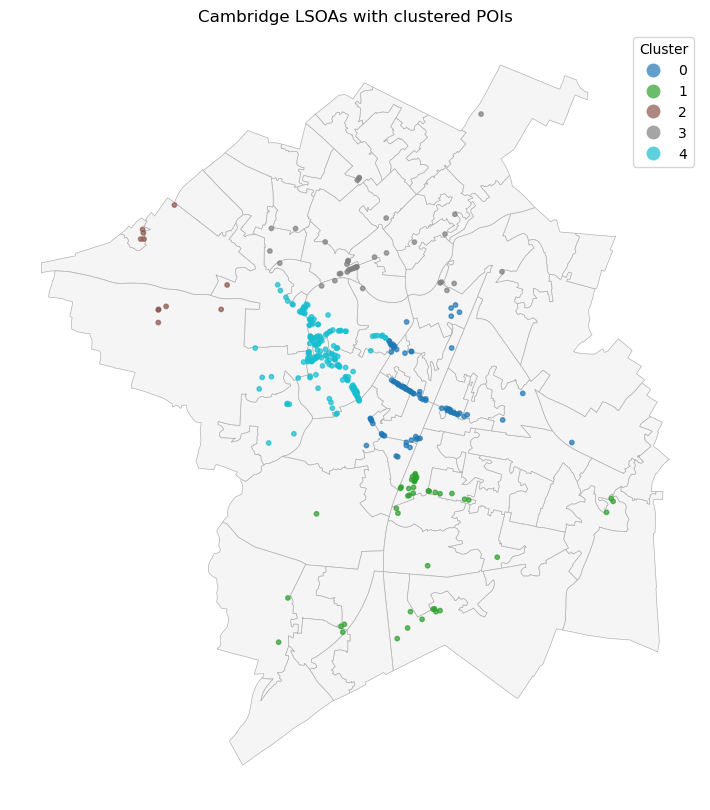

In [47]:
# Plot clustered POIs
fig, ax = plt.subplots(figsize=(10, 10))

# base: the neighbourhoods
cambridge_lsoas_gdf.plot(
    ax=ax, 
    facecolor="whitesmoke", 
    edgecolor="0.7", 
    linewidth=0.5
)

cambridge_pois_reprojected.plot(
    ax=ax,
    column="cluster",
    categorical=True,
    cmap="tab10",
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={"title": "Cluster", "loc": "upper right"},
)

ax.set_title("Cambridge LSOAs with clustered POIs")
ax.set_axis_off()
plt.show()

In [48]:
# Find distance from each LSOA's centroid to its nearest cluster centre
cambridge_tree = cKDTree(cambridge_cluster_centres)
cambridge_dists, cambridge_closest_cluster = cambridge_tree.query(cambridge_access_df[["BNG_E", "BNG_N"]].values)
cambridge_access_df["dist_to_nearest_cluster_centre"] = cambridge_dists
cambridge_access_df["nearest_cluster"] = cambridge_closest_cluster

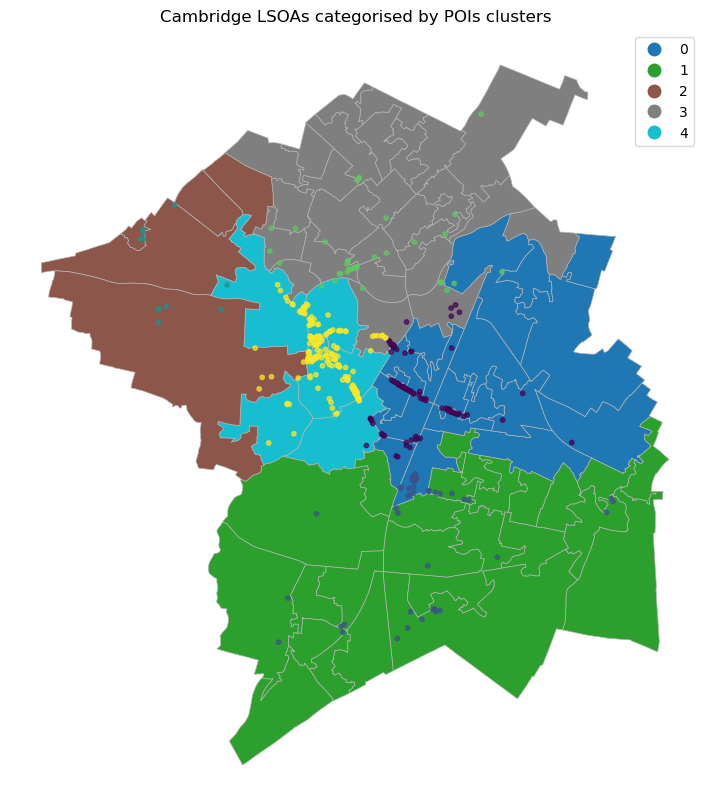

In [49]:
# Plotting LSOAs based on POIs clusters' categories
fig, ax = plt.subplots(figsize=(10, 10))

# base: the neighbourhoods
cambridge_lsoas_gdf.plot(
    ax=ax,
    column=cambridge_access_df["nearest_cluster"].values,  # values to colour by
    categorical=True,                          # discrete colours, not a gradient
    cmap="tab10",                              # qualitative colormap
    legend=True,
    edgecolor="0.7",
    linewidth=0.5,
)

# overlay: the POIs, coloured by type
cambridge_pois_reprojected.plot(
    ax=ax, markersize=10, alpha=0.7, legend=True, c=cambridge_cluster_label,
)

ax.set_title("Cambridge LSOAs categorised by POIs clusters")
ax.set_axis_off()
plt.show()

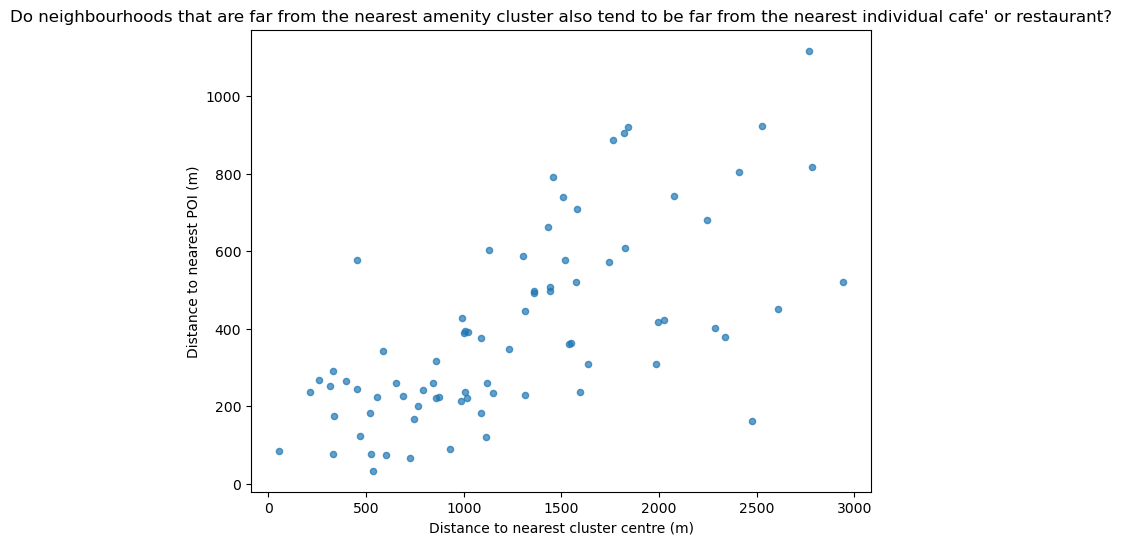

In [50]:
# Check the relationship between the distance of the LSOA's centroid
# to the nearest cluster centre vs the distance from the LSOA's centroid's to their nearest POI
fig, ax = plt.subplots(figsize=(8, 6))
cambridge_access_df.plot.scatter(
    ax=ax, x="dist_to_nearest_cluster_centre", y="dist_to_nearest_poi", alpha=0.7
)
ax.set_xlabel("Distance to nearest cluster centre (m)")
ax.set_ylabel("Distance to nearest POI (m)")
ax.set_title(
    "Do neighbourhoods that are far from the nearest amenity cluster also tend to be far from the nearest individual cafe' or restaurant?"
)
plt.show()

In [51]:
cambridge_polycentric_r, cambridge_polycentric_p = stats.pearsonr(
    cambridge_access_df["dist_to_nearest_cluster_centre"],
    cambridge_access_df["dist_to_nearest_poi"],
)
print(f"r = {cambridge_polycentric_r:.2f},  p = {cambridge_polycentric_p:.3f}")

r = 0.67,  p = 0.000
